# Введение в регрессионный анализ: интенсив по Python

*Алла Тамбовцева*

## Семинар 7. Примеры визуализации с Matplotlib

[Charity Navigator](https://www.charitynavigator.org/about-us/our-methodology/ratings/#accordion-0f1da9ef58-item-57920c7dce) – благотворительная организация, которая занимается независимой оценкой некоммерческих организаций в США. На основе налоговых деклараций и информации с сайтов самих некоммерческих организаций организация формирует числовые индексы качества работы организаций, а затем – рейтинги на основе этих индексов. Два основных направления оценки:

* финансовое благополучие;
* подотчётность и прозрачность.

Итак, есть индекс финансового благополучия *Financial Score* и индекс подотчётности и прозрачности *Accountability & Transparency Score*, оба индекса измерены в шкале от 0 до 100, где большие значения соответствуют лучшему качеству работы организации. Также сформирован общий индекс *Score*, в состав которого входят *Financial Score* и *Accountability & Transparency Score*.

Итак, в файле `charity_data.csv` (скачать [здесь](https://github.com/allatambov/PyReg26/blob/main/charity_data.csv)) хранится информация по некоммерческим организациям США. Некоторые показатели в файле:

* `name`: название организации;
* `category`: профиль организации;
* `description`: описание организации;
* `motto`: девиз организации;
* `size`: размер организации;
* `state`: штат, в котором находится организация;
* `ascore`: индекс подотчётности и прозрачности;
* `fscore`: индекс финансового благополучия;
* `score`: общий индекс качества работы организации.

Подробнее о данных можно почитать на платформе [Kaggle](https://www.kaggle.com/datasets/katyjqian/charity-navigator-scores-expenses-dataset), именно оттуда этот файл был взят.

Импортируем библиотеки `pandas` и `numpy`, а также модуль `pyplot` из графической библиотеки `matplotlib`:

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### Немного теории

В этом модуле есть функция `subplots()`, которая создает один или несколько подграфиков внутри одного изображения. Так, мы можем создать заготовку для одного графика:

(<Figure size 640x480 with 1 Axes>, <Axes: >)

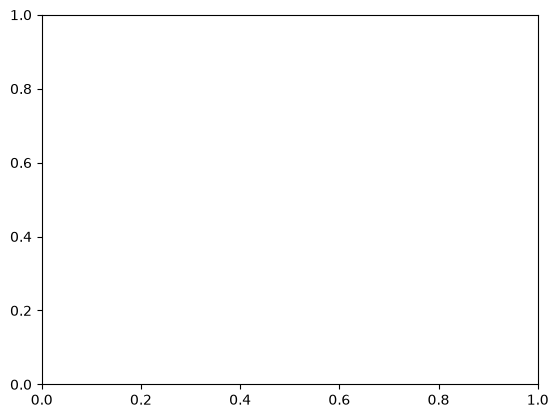

In [2]:
plt.subplots()

А можем создать сетку из графиков из одной строки и трёх столбцов, то есть поставить три графика в один ряд:

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

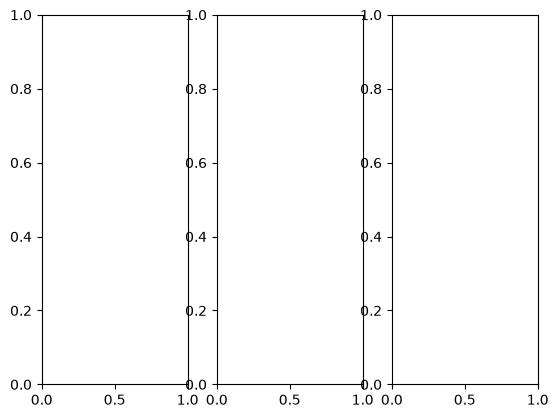

In [3]:
plt.subplots(nrows = 1, ncols = 3)

Пока это набор из пустых координатных плоскостей (массив из осей `AxesSubplot`) внутри одной картинки (изображение `Figure` фиксированного размера). При дальнейшей работе мы будем вносить изменения в каждую координатную плоскость `AxesSubplot`, а затем обновлённый результат в `Figure` выгружать в файл, например, с расширением `.jpeg` или `.png`.

Для этого сохраним результаты, возвращённые функцией, в переменные. Проделаем это на примере одного графика. Так как первый результат – это изображение, его часто называют `fig` (от *figure*). Второй результат – это набор осей, его обычно сокращают до `ax` (*axes*).

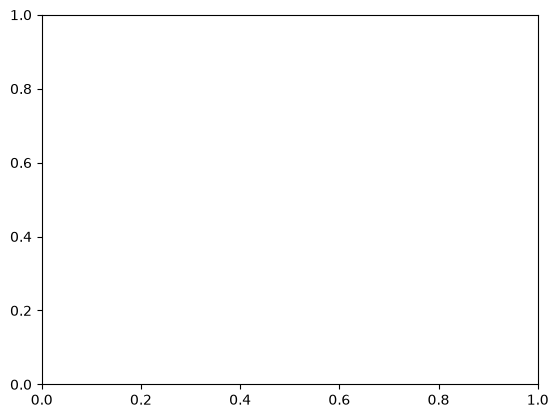

In [4]:
fig, ax = plt.subplots();

К набору осей можно применять разные методы для построения графиков (например, `.hist()`, `.boxplot()`) или их оформления (дрбавление подписей, координатной сетки и прочего).

### Задача 1

Загрузите данные из файла `charity_data.csv` и сохраните их в датафрейм `data`. Выведите «техническую» информацию по датафрейму `data`, включающую перечень столбцов, их типы и пропущенные значения.

In [5]:
data = pd.read_csv("charity_data.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8408 entries, 0 to 8407
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ascore         8408 non-null   float64
 1   category       8408 non-null   str    
 2   description    8408 non-null   str    
 3   ein            8408 non-null   str    
 4   tot_exp        8408 non-null   float64
 5   admin_exp_p    8408 non-null   float64
 6   fund_eff       8408 non-null   float64
 7   fund_exp_p     8408 non-null   float64
 8   program_exp_p  8408 non-null   float64
 9   fscore         8408 non-null   float64
 10  leader         8408 non-null   str    
 11  leader_comp    7972 non-null   float64
 12  leader_comp_p  7972 non-null   float64
 13  motto          8394 non-null   str    
 14  name           8408 non-null   str    
 15  tot_rev        8408 non-null   float64
 16  score          8408 non-null   float64
 17  state          8408 non-null   str    
 18  subcategory    8408

### Задача 2

Выберите из датафрейма `data` столбцы `name`, `state`, `category`, `size`, `ascore`, `fscore`, `score` и сохраните их в новый датафрейм `char`.

Подсказка: пример выбора столбцов `A`, `B`, `C` из датафрейма `df`:

    df[["A", "B", "C"]]

In [6]:
# внешние квадратные скобки – как фильтр для выбора столбцов
# внутренние квадратные скобки – границы списка с названиями

char = data[["name", "state", "category", "size", 
             "ascore", "fscore", "score"]]
char

,name,state,category,size,ascore,fscore,score
0,1000 Friends of Oregon,OR,Environment,small,100.0,88.61,91.94
1,WYPR,MD,"Arts, Culture, Humanities",mid,89.0,82.85,85.59
2,VSS Catholic Communications,NE,Religion,small,70.0,86.74,76.80
3,Utah Symphony & Opera,UT,"Arts, Culture, Humanities",big,93.0,91.03,91.95
4,Two Ten Footwear Foundation,MA,Human Services,mid,100.0,86.23,90.26
...,...,...,...,...,...,...,...
8403,Yaddo,NY,"Arts, Culture, Humanities",small,92.0,71.94,79.36
8404,Yad L'Achim Peyle Israel,NY,Religion,small,59.0,60.71,59.84
8405,Yad Ezra,MI,Human Services,small,100.0,83.13,88.07
8406,Rawhide,WI,Human Services,big,100.0,95.64,96.91


### Задача 3

Выберите из датафрейма `char` строки, соответствующие профилям деятельности `Arts, Culture, Humanities` или `Education`. Сохраните их в датафрейм `chosen`. Далее мы будем работать именно с датафреймом `chosen`.

In [7]:
# метод .isin() – альтернатива условия c | 
# проверяет, входит ли значение в перечень внутри .isin()

chosen = char[char["category"].isin(["Arts, Culture, Humanities", "Education"])]
print(chosen.shape) # проверяем число строк

(1885, 7)


### Задача 4

Постройте гистограмму для индекса подотчётности и прозрачности, измените цвет заливки и цвет границ столбцов. Измените число столбцов в построенной гистограмме, указав желаемое число столбцов в аргументе `bins` внутри метода `.hist()`. Число столбцов выберите самостоятельно.

Подсказка: примените метод `.hist()` к осям `ax`, в качестве аргумента внутри метода укажите соответствующий столбец таблицы.

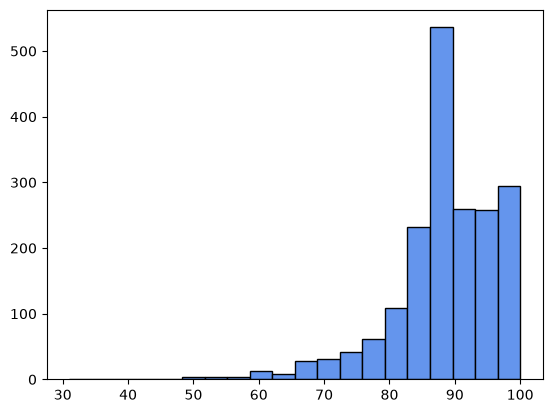

In [8]:
fig, ax = plt.subplots();

# color – цвет заливки
# edgecolor – цвет границ столбцов
# bins – число столбцов
# порядок аргументов после char["ascore"] не важен

ax.hist(chosen["ascore"], color = "cornflowerblue", 
        edgecolor = "black", bins = 20);

### Задача 5

Добавьте к гистограмме, созданной выше:

* подписи по горизонтальной и вертикальной осям (методы `.set_xlabel()` и `.set_ylabel()`);
* координатную сетку (метод `.grid()`).

Чтобы убрать координатную сетку под график (иначе она перекрывает гистограмму, что не очень красиво), можно применить метод `.set_axisbelow()` и указать внутри `True`.

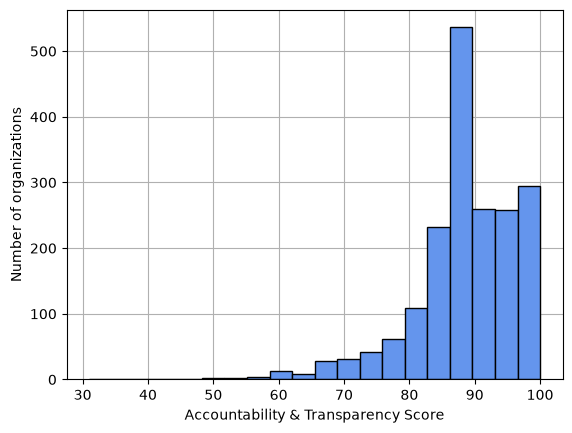

In [9]:
# не теряйте строку с fig и ax, график строится «по слоям»,
# мы должны добавлять эти слои к объектам fig, ax, созданным 
# в рамках текущей программы (ячейки в Jupyter)

fig, ax = plt.subplots();

ax.hist(chosen["ascore"], color = "cornflowerblue", 
        edgecolor = "black", bins = 20);
ax.set_xlabel("Accountability & Transparency Score");
ax.set_ylabel("Number of organizations");
ax.grid();
ax.set_axisbelow(True);

### Задача 6

Измените шаг построенной гистограммы – сделайте его равным стандартному отклонению показателя. Для этого сохраните в переменные `min_`, `max_` и `std_` минимум, максимум и стандартное отклонение, посчитанные по выборке в столбце `ascore`, и подставьте `new_bins` в аргумент `bins`.

Экспортируйте полученный график с гистограммой в файл `ascore_hist.png`. Для экспорта примените метод `.savefig()` к изображению `fig` и укажите в качестве аргумента внутри название файла.

In [10]:
min_ = chosen["ascore"].min()
max_ = chosen["ascore"].max()
std_ = chosen["ascore"].std()

# new_bins – новые границы столбцов,
# высоты столбцов под новое деление Python вычислит сам

new_bins = np.arange(min_, max_ + 1, std_)
print(new_bins)

[31.         39.45018587 47.90037174 56.35055761 64.80074348 73.25092935
 81.70111522 90.1513011  98.60148697]


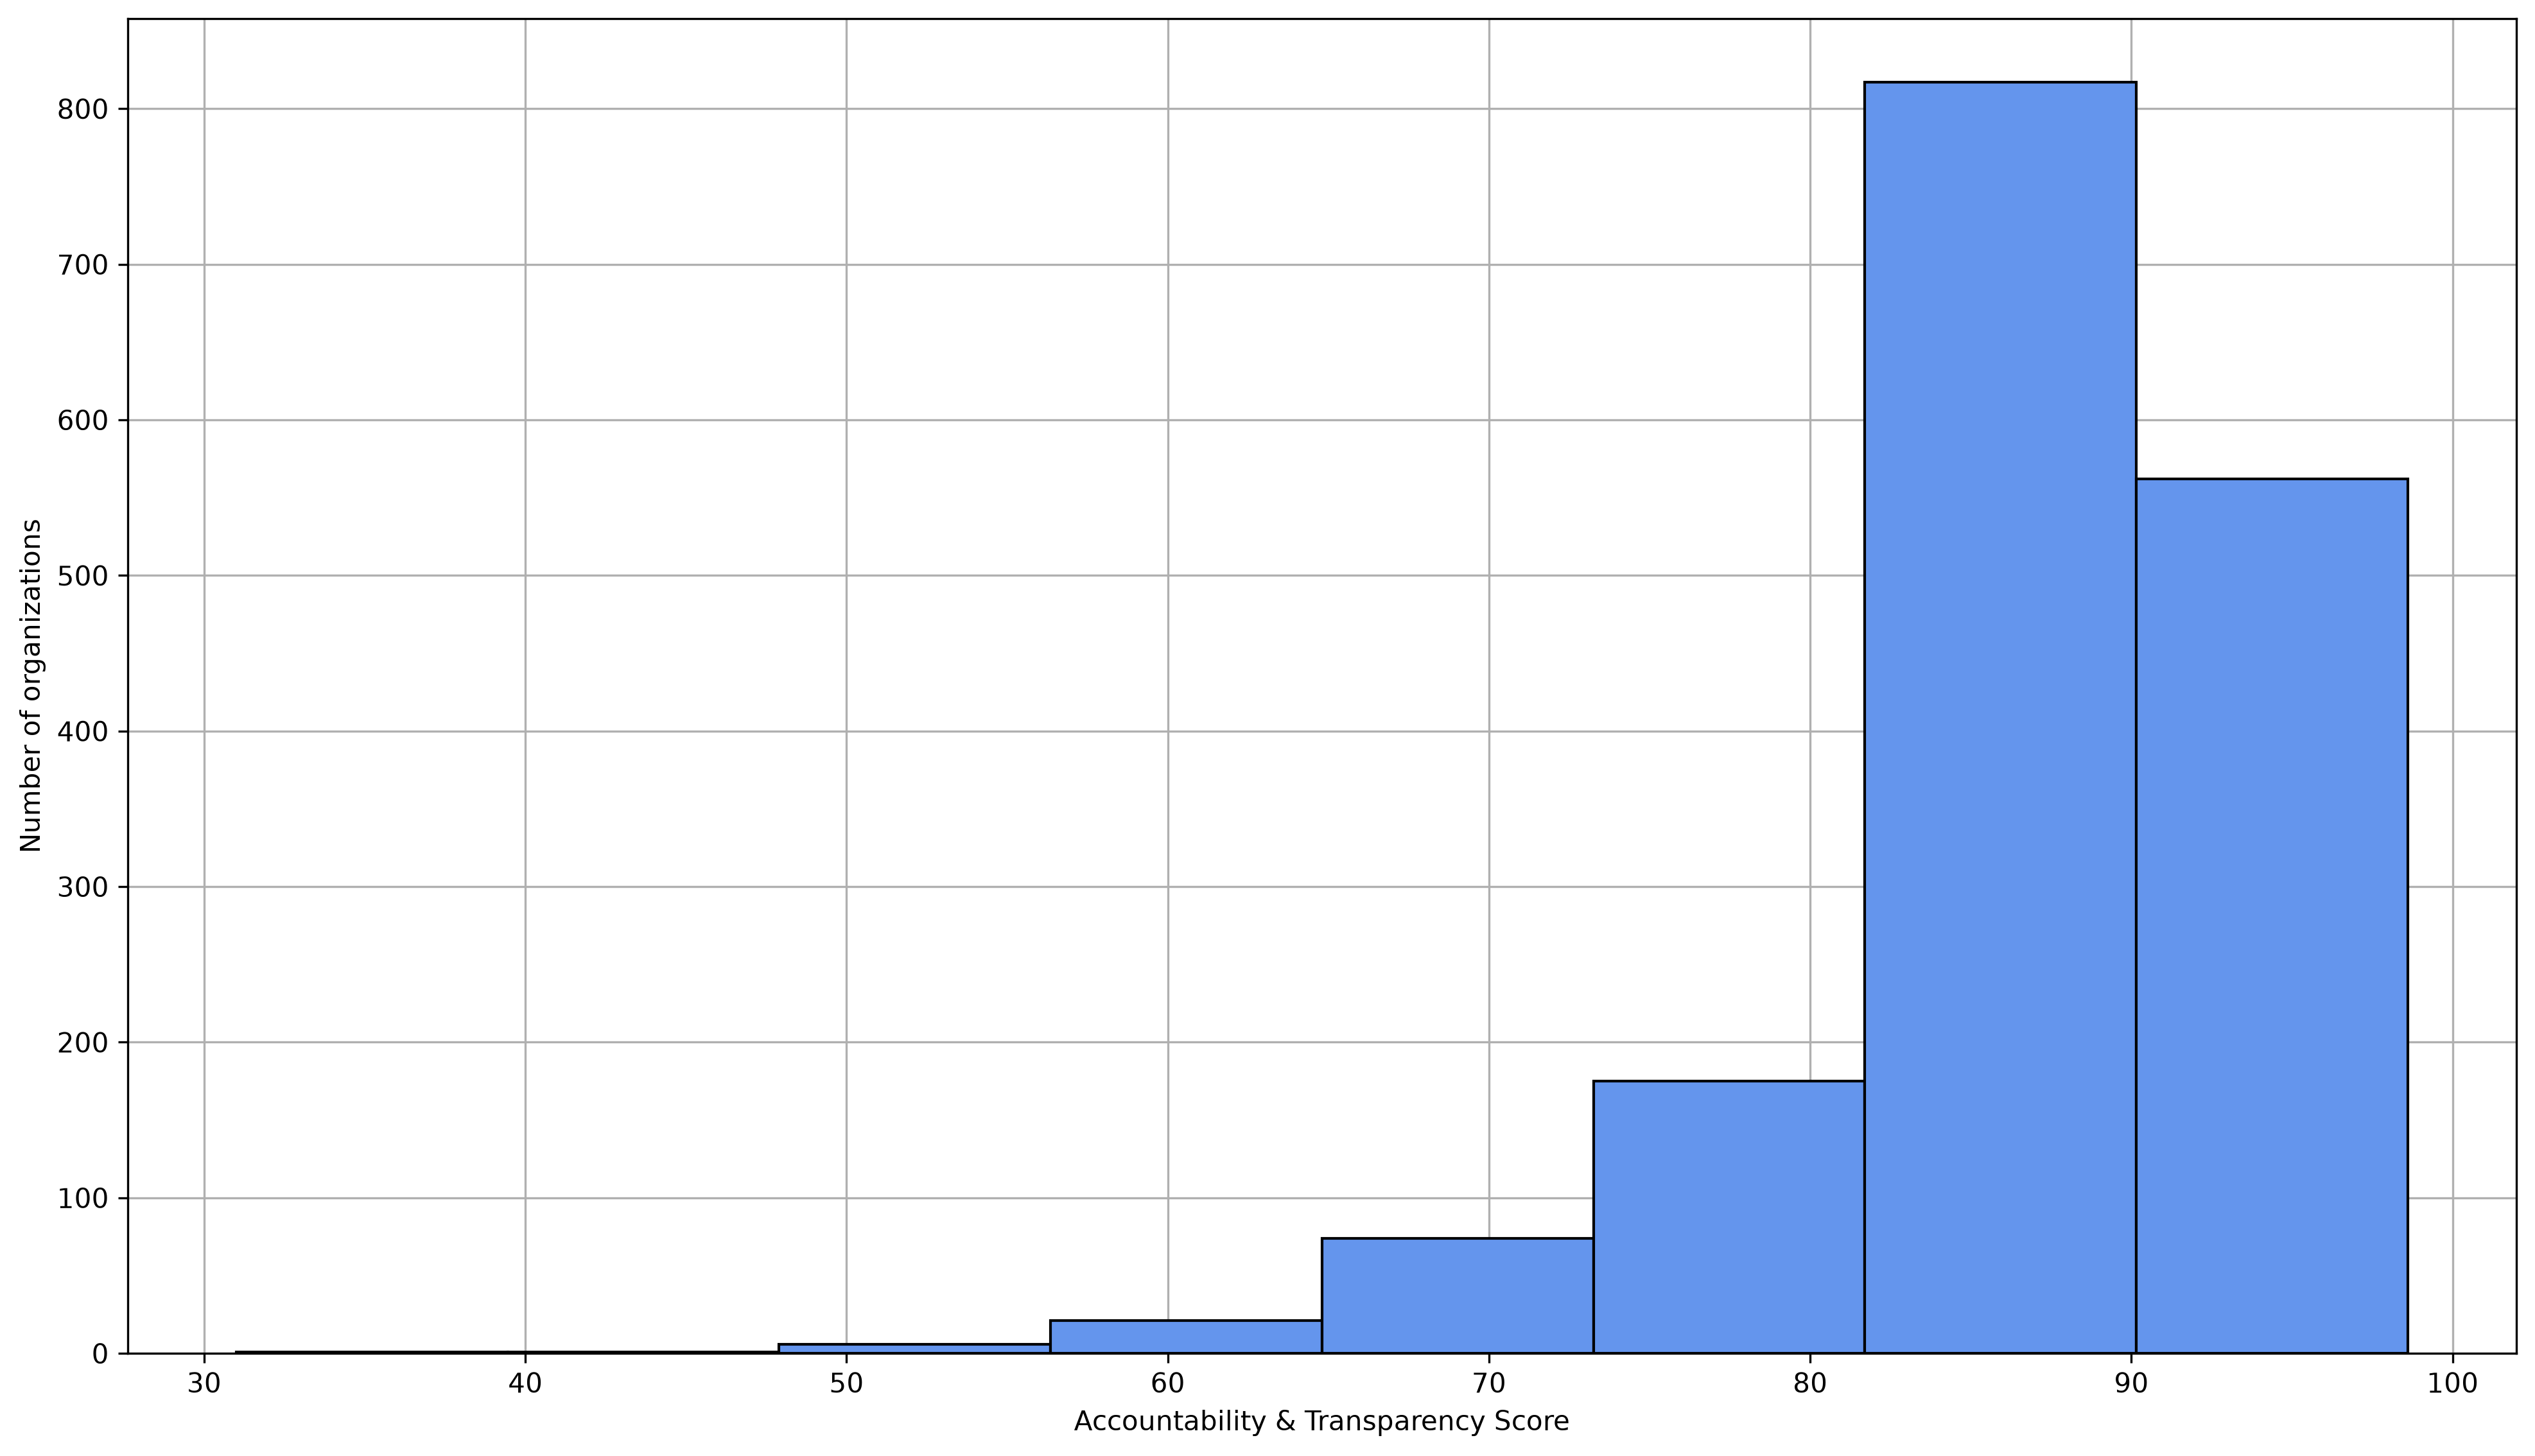

In [11]:
# шаг 1: заменяем 20 в bins на new_bins внутри .hist()
# шаг 2: изменяем в .subplots() размер и разрешение картинки, 
# чтобы экспортировать ее в хорошем качестве
# figsize – ширина и высота в дюймах, 
# dpi – разрешение, число точек на дюйм, dots per inch
# шаг 3: экспортируем через .savefig()

fig, ax = plt.subplots(figsize = (16, 9), dpi = 300);

ax.hist(chosen["ascore"], color = "cornflowerblue", 
        edgecolor = "black", bins = new_bins);
ax.set_xlabel("Accountability & Transparency Score");
ax.set_ylabel("Number of organizations");
ax.grid();
ax.set_axisbelow(True);

fig.savefig("ascore.png")

> **Важно.** Файл с графиком был сохранен в рабочую папку – ту, которая используется по умолчанию Jupyter и которая отображается во вкладке *Home*. Если нужен путь к этой папке, можно импортировать модуль `os` (от *operating system*, модуль для взаимодействия с системой) и вызвать функцию `getcwd()` для получения пути к текущей рабочей папке (от *get current working directory):*

In [12]:
import os
print(os.getcwd()) # тут надо искать картинку

/Users/allat/Documents/Кафедра высшей математики/2026-2027/Введение в регрессионный анализ/week03/practice


### Задача 7

Постройте два графика в рамках одного изображения (два графика в одной строке):

* гистограмму для `ascore`;
* ящик с усами для `ascore`.

Для этого выберите из `axes` первый и второй элемент и примените к ним соответствующие методы.

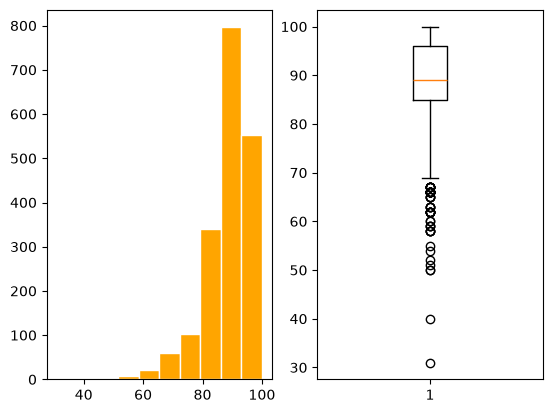

In [13]:
fig, axes = plt.subplots(nrows = 1, ncols = 2);

# выбор элементов – как обычно в списках или массивах,
# axes[0] – первый набор осей, axes[1] – второй набор осей

axes[0].hist(chosen["ascore"], color = "orange", edgecolor = "white");
axes[1].boxplot(chosen["ascore"]);

### Задача 8

По аналогии с предыдущей задачей постройте в рамках одного изображения гистограммы (каждая гистограмма в своём окне) для следующих показателей: 

* индекс финансового благополучия (`fscore`);
* индекс подотчётности и прозрачности (`ascore`);
* общий индекс качества работы (`score`).

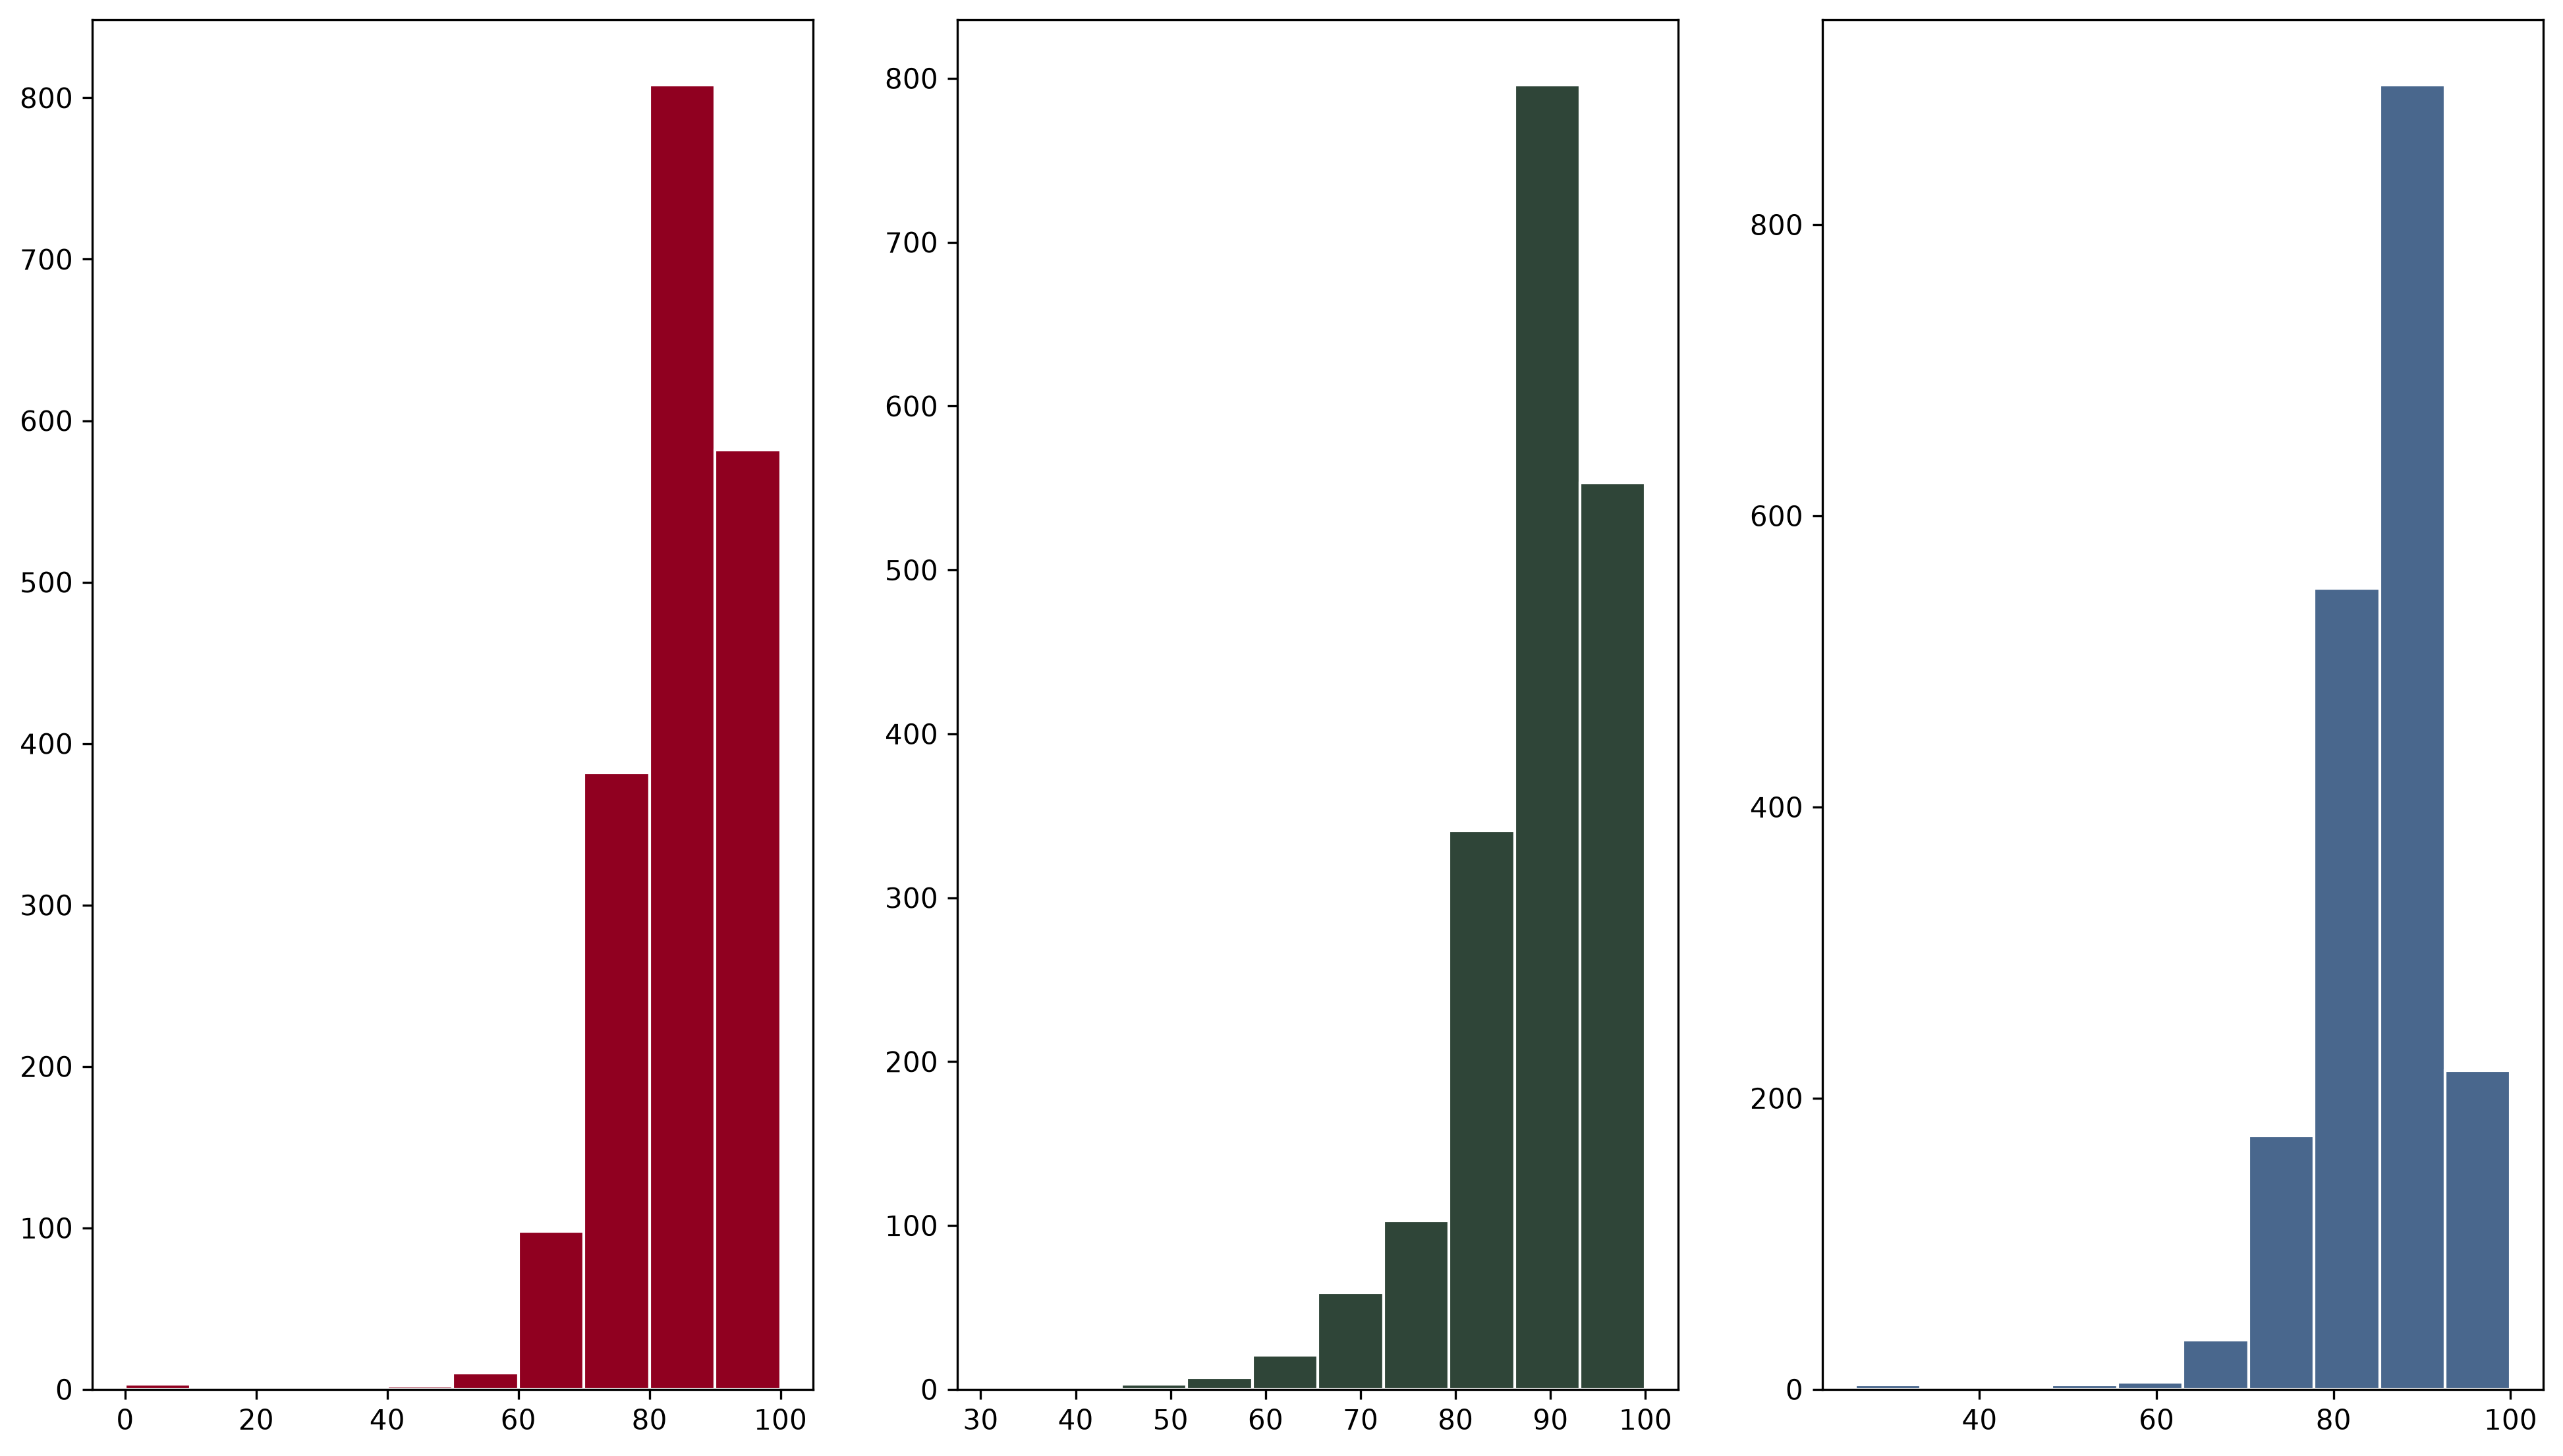

In [14]:
# уже 3 столбца, ncols = 3
# делаем график побольше

fig, axes = plt.subplots(nrows = 1, ncols = 3, 
                         figsize = (16, 9), dpi = 300);

# тут уже три набора осей, выбираем по индексам 0, 1, 2
# цвета – бургундский, зеленый мох, отдаленно-синий

axes[0].hist(chosen["fscore"], color = "#900020", edgecolor = "white");
axes[1].hist(chosen["ascore"], color = "#2F4538", edgecolor = "white");
axes[2].hist(chosen["score"], color = "#49678D", edgecolor = "white");

**Дополнительно.** Если мы захотим добавить другие элементы (подписи, сетку, легенду) на графики, соответствующие методы придется применять отдельно к каждым осям. Например, `axes[0].grid()`, `axes[1].grid()`, `axes[2].grid()`. Но, к счастью, существуют циклы:

In [ ]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, 
                         figsize = (16, 9), dpi = 300);
axes[0].hist(chosen["fscore"], color = "#900020", edgecolor = "white");
axes[1].hist(chosen["ascore"], color = "#2F4538", edgecolor = "white");
axes[2].hist(chosen["score"], color = "#49678D", edgecolor = "white");

# перебираем все три набора осей axes,
# везде одинаково добавляем сетку

for ax in axes:
    ax.grid();
    ax.set_axisbelow(True);

Что стоит скорректировать?

* Чтобы распределения показателей удобнее было сравнивать между собой (не только по форме гистограммы), нужно зафиксировать одинаковый масштаб по горизонтальной оси – от 0 до 100 с шагом 10. В данном случае достаточно изменить границы столбцов у гистограмм – поместить в `bins` набор целых чисел от 0 до 100 с шагом 10, созданный через обычный `range()`.
* Из-за схожих соображений скорректируем масштаб по вертикальной оси – можем указать границы по оси `y` в методе `.set_ylim()` и применить его в цикле.
* Добавить подписи по горизонтальной оси – названия индексов. Добавить подписи по вертикальной оси – везде число организаций, достаточно указать только у первого графика, раз здесь три в ряд.

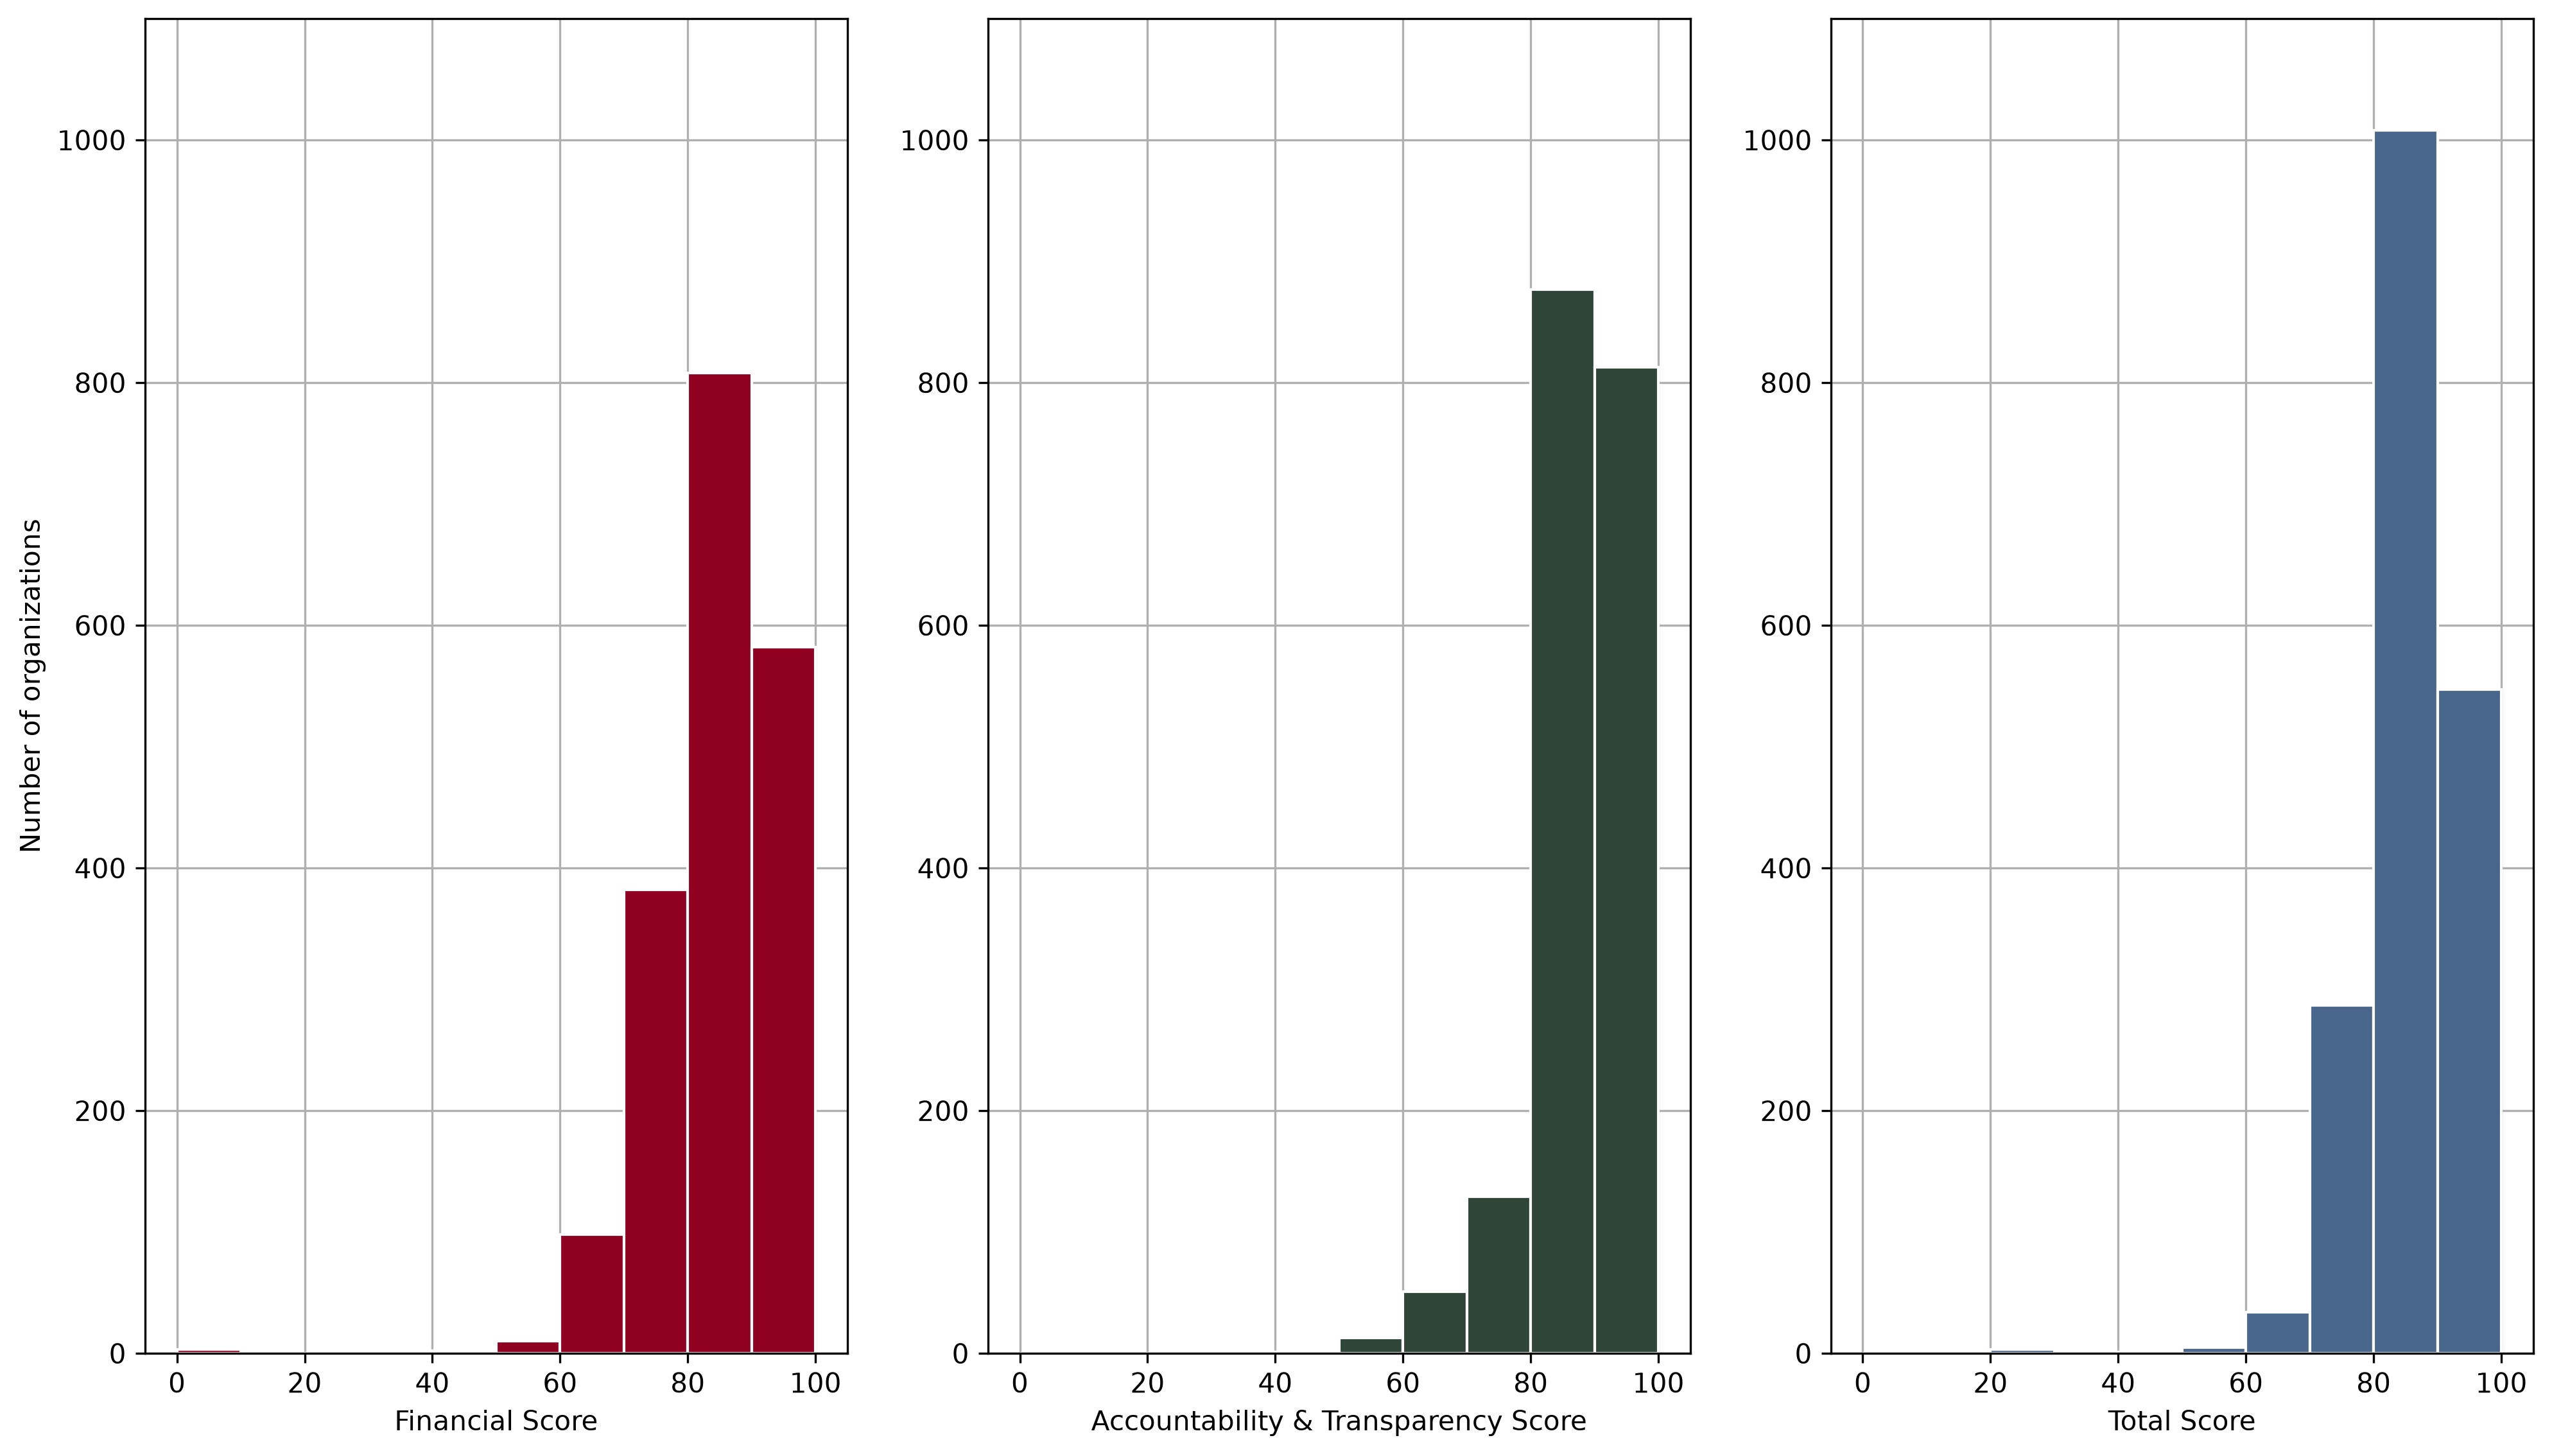

In [15]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, 
                         figsize = (16, 9), dpi = 300);

axes[0].hist(chosen["fscore"], color = "#900020", edgecolor = "white", 
             bins = range(0, 101, 10));
axes[0].set_xlabel("Financial Score");

axes[1].hist(chosen["ascore"], color = "#2F4538", edgecolor = "white", 
             bins = range(0, 101, 10));
axes[1].set_xlabel("Accountability & Transparency Score");

axes[2].hist(chosen["score"], color = "#49678D", edgecolor = "white", 
             bins = range(0, 101, 10));
axes[2].set_xlabel("Total Score");

axes[0].set_ylabel("Number of organizations");

for ax in axes:
    ax.set_ylim((0, 1100))
    ax.grid();
    ax.set_axisbelow(True);

Для больших любителей циклов (да, мне тоже не нравится одинаковый код, который просто копируется для каждого показателя) – функция `zip()` нам в помощь:

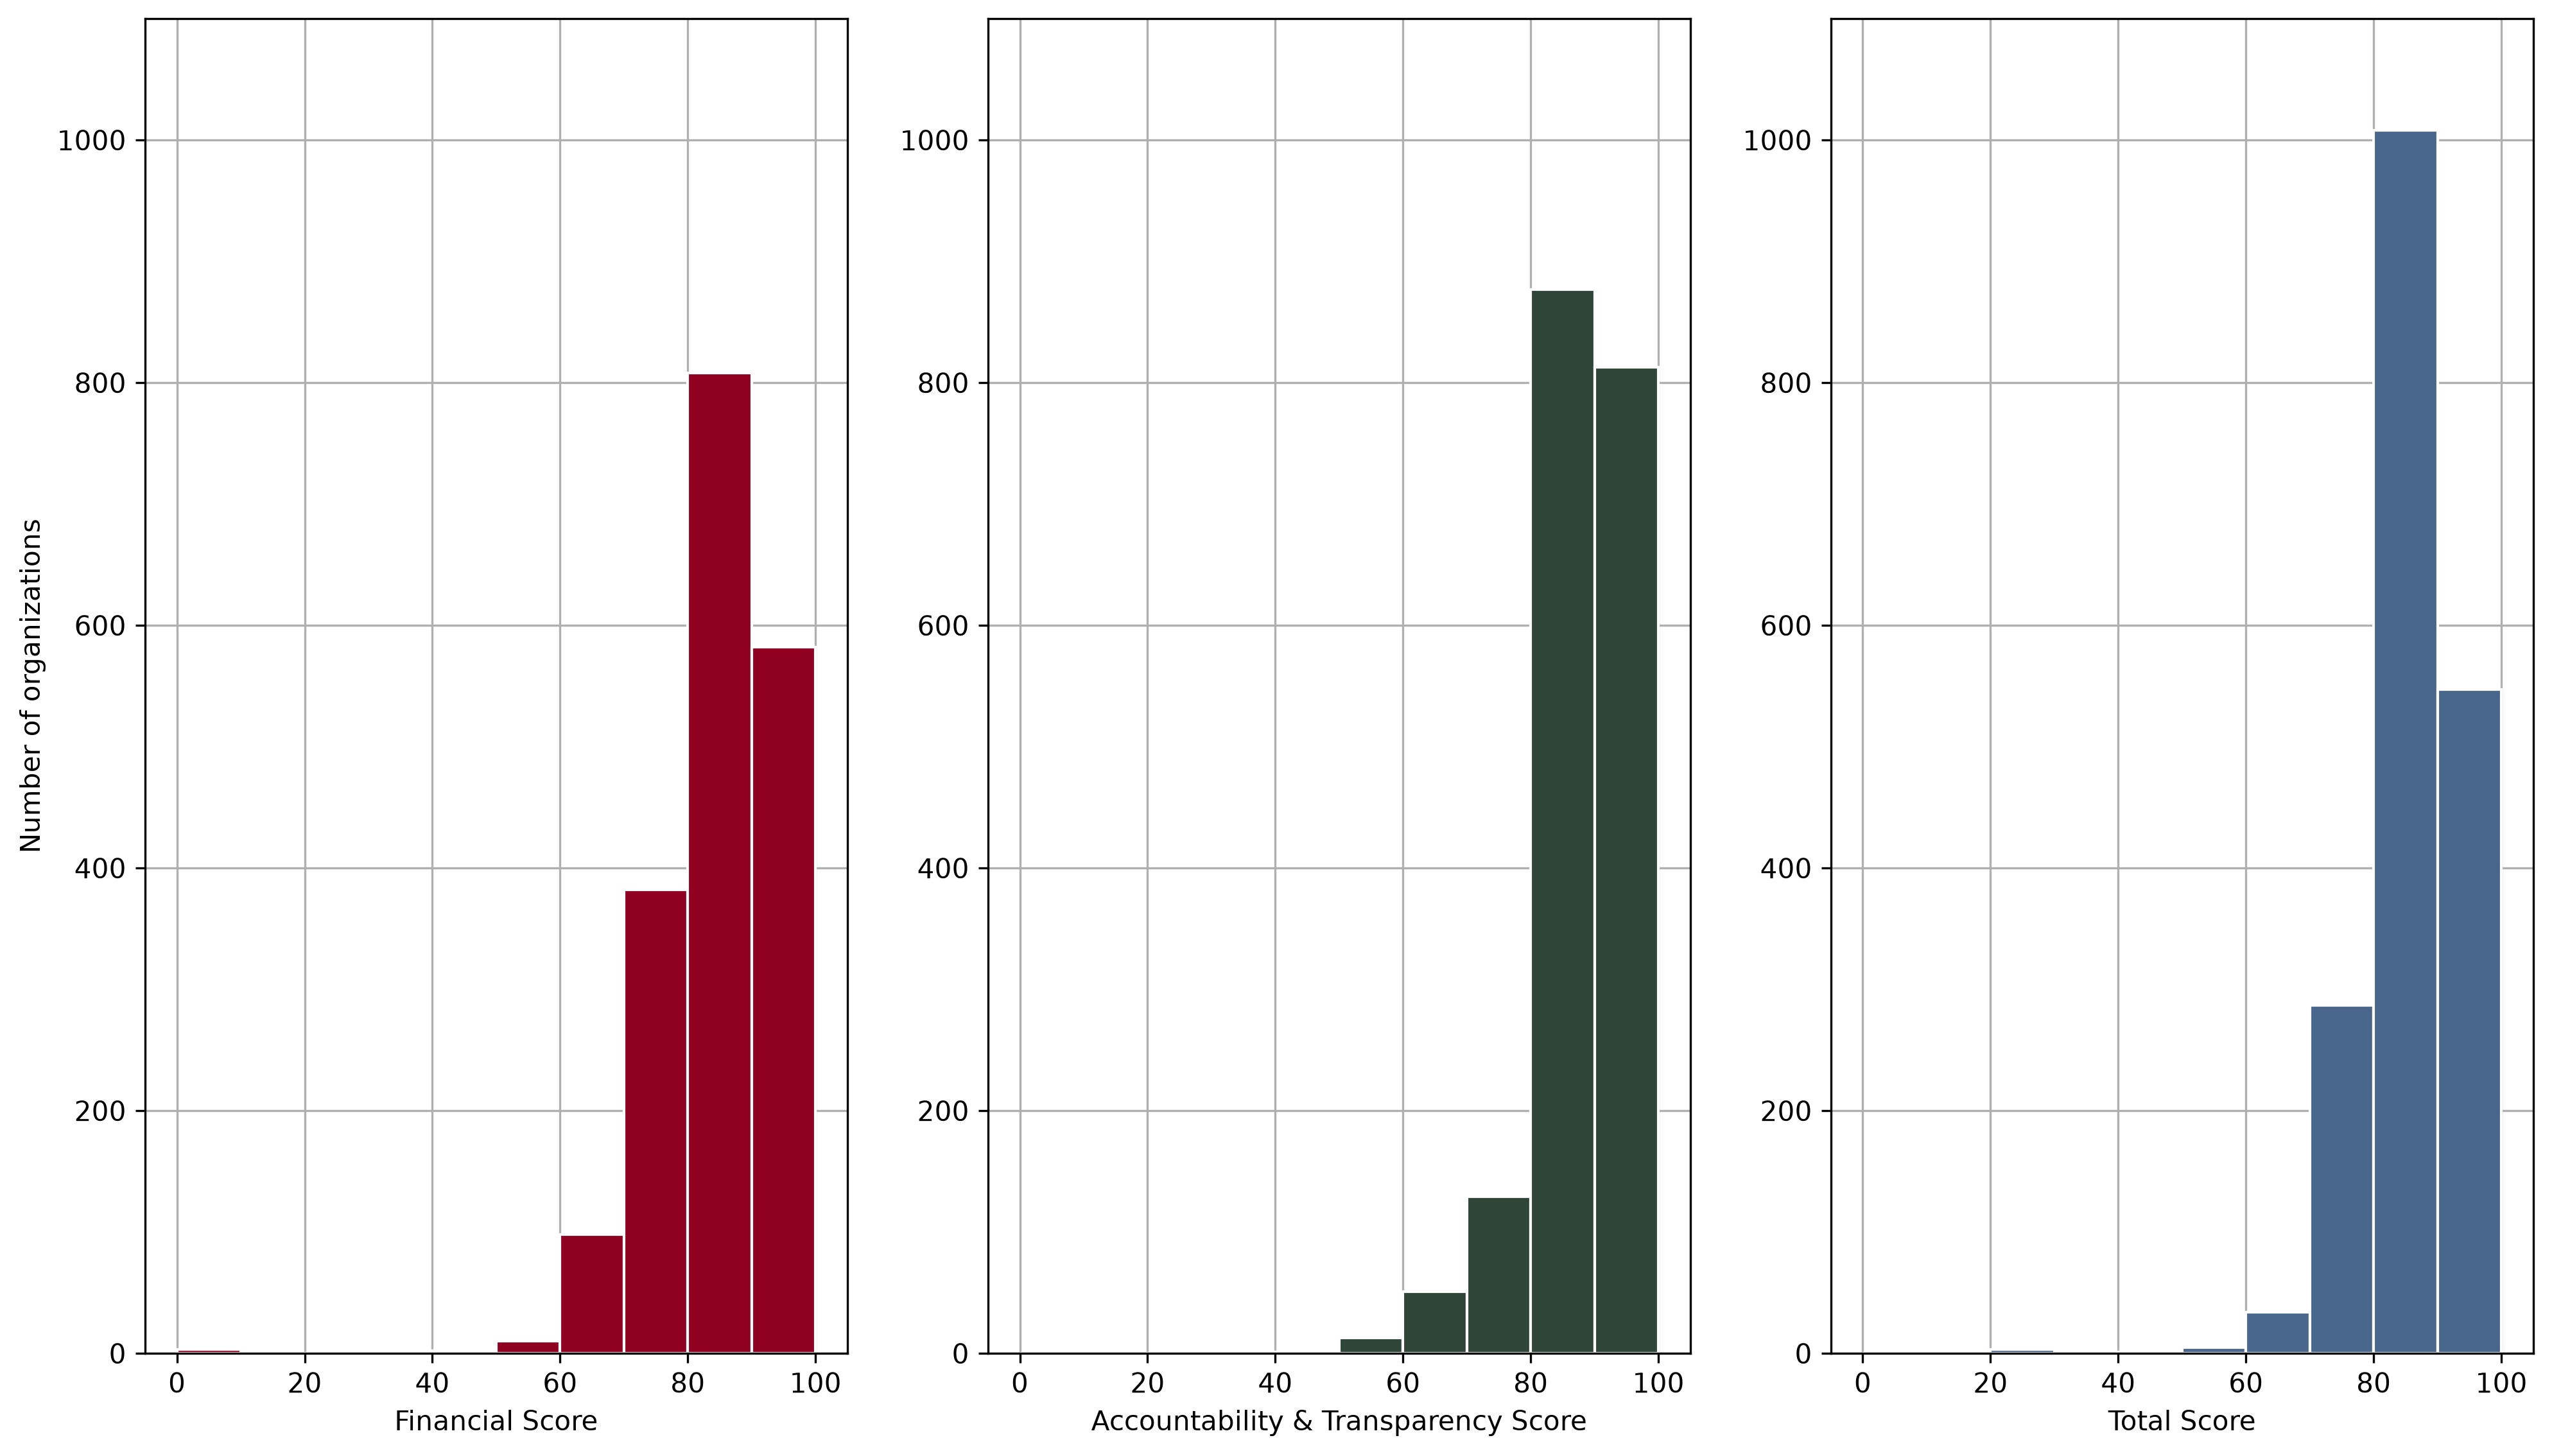

In [16]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, 
                         figsize = (16, 9), dpi = 300);

columns = [chosen["fscore"], chosen["ascore"], chosen["score"]]
colors = ["#900020", "#2F4538", "#49678D"]
names = ["Financial Score", "Accountability & Transparency Score", "Total Score"]

for column, col, name, ax in zip(columns, colors, names, axes):
    ax.hist(column, color = col, edgecolor = "white", bins = range(0, 101, 10))
    ax.set_xlabel(name)
    ax.set_ylim((0, 1100))
    ax.grid();
    ax.set_axisbelow(True);

axes[0].set_ylabel("Number of organizations");

Функция `zip()` объединяет списки в списки кортежей из соответствующих элементов (все первые элементы списков, все вторые, и так далее). Вот, например, как выглядит результат только для цветов и названий: 

In [17]:
print(list(zip(colors, names)))

# color – первый элемент в паре
# name – второй элемент в паре

for color, name in zip(colors, names):
    print(f"цвет: {color}, название: {name}")

[('#900020', 'Financial Score'), ('#2F4538', 'Accountability & Transparency Score'), ('#49678D', 'Total Score')]
цвет: #900020, название: Financial Score
цвет: #2F4538, название: Accountability & Transparency Score
цвет: #49678D, название: Total Score


В коде для графиков `zip()` создает наборы из 4 элементов: столбец с данными, цвет, название столбца, оси графика. Благодаря этому мы точно можем на каждом шаге цикла первый элемент `column` подставить на место данных в `hist()`, второй `col` – на место цвета в `color`, третий `name` – на место подписи в `set_xlabel()`. А четвертый `ax` – это оси графика, в которые мы все это добавляем.